In [36]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [37]:
#Load dataset
df = pd.read_csv("F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Email_Spam_Detection_Using_ML/Data/spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']
print(df.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [26]:
#Preprocess
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

In [38]:
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    return text

df['message'] = df['message'].apply(clean_text)

print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


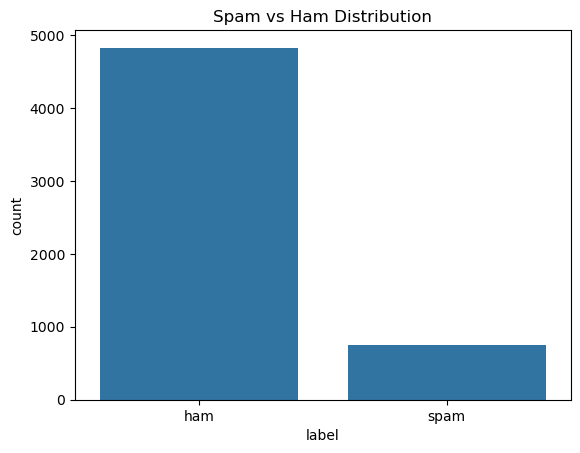

In [46]:
#Visualization
sns.countplot(x=df['label'])
plt.title("Spam vs Ham Distribution")
plt.savefig("F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Email_Spam_Detection_Using_ML/Graphs/spam_distribution.png")
plt.show()
plt.close()

In [47]:
#Feature Extraction
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['message'])
y = df['label']

In [48]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
#Train Model
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [50]:
#Predictions
y_pred = model.predict(X_test)

In [51]:
#Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.967713004484305


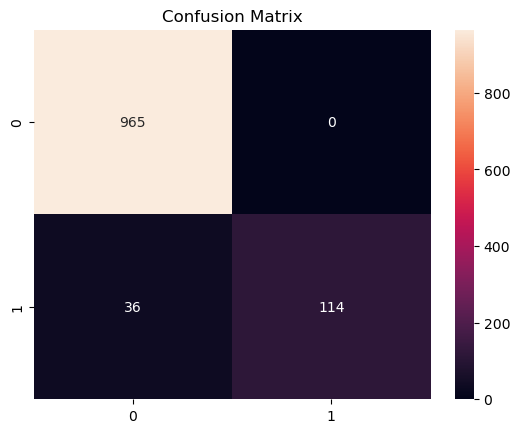

In [54]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.savefig("F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Email_Spam_Detection_Using_ML/Graphs/confusion_matrix.png")
plt.show()

In [55]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       965
        spam       1.00      0.76      0.86       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



In [56]:
#Saving Model and Vectorizer
pickle.dump(model, open("F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Email_Spam_Detection_Using_ML/Model/spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("F:/OneDrive/Documents/OASIS_INFOBYTE_INTERNSHIP/Email_Spam_Detection_Using_ML/Model/vectorizer.pkl", "wb"))

In [57]:
#Prediction function
def predict_spam(text):
    text_cleaned = clean_text(text)
    vectorized_text = vectorizer.transform([text_cleaned])
    prediction = model.predict(vectorized_text)[0]
    
    if prediction == 1:
        return "Spam"
    else:
        return "Not Spam"

print(predict_spam("Congratulations! You won a free lottery"))
print(predict_spam("Hi, are we meeting tomorrow?"))

Not Spam
Not Spam


In [58]:
#Insights
#The dataset shows slight class imbalance between spam and non-spam emails
#TF-IDF effectively captures important keywords for classification
#Naive Bayes performs well due to probabilistic nature of text data
#Recall is more important than accuracy in spam detection
#The model struggles with context and sophisticated phishing messages
#Feature engineering plays a crucial role in improving performance